# Testanto modelo NGBoost para predição de Resistência à compressão do concreto

In [1]:
%%capture
!pip install ngboost

In [2]:
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import GroupKFold, cross_val_score
from ngboost.distns import Normal
from ngboost import NGBRegressor
from ngboost.scores import MLE
import matplotlib.pyplot as plt
from google.colab import drive
from tqdm.notebook import tqdm
from scipy import stats
from scipy.stats import spearmanr
import os, math
import seaborn as sns
import pandas as pd
import numpy as np

In [3]:
dirpath = '/content/drive/MyDrive/supervised-learning-studies/projeto/resistencia'
filename = 'df_resistencia_NGBoost.pkl'
file_path = os.path.join(dirpath, filename)
os.listdir(dirpath)
df = pd.read_pickle(file_path)
df['target'] = df['Resistencia_Compressao_MPa'].copy()
df.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 207 entries, 16 to 598
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   fib_estimativa_base             207 non-null    float64
 1   vol_areia                       207 non-null    float64
 2   feret_corrigido_contorno        207 non-null    float64
 3   cinetica_real                   207 non-null    float64
 4   Agua_kg_m3                      207 non-null    float64
 5   Relacao_Agua_Cimento            207 non-null    float64
 6   aci_desvio_cimento              207 non-null    float64
 7   idade_parametro_feret_filer_k5  207 non-null    float64
 8   Autores/ano                     207 non-null    object 
 9   vol_cimento                     207 non-null    float64
 10  vol_filer                       207 non-null    float64
 11  Relacao_Agua_Aglomerante        207 non-null    float64
 12  vol_sp                          207 non-

In [4]:
n_groups = df['Autores/ano'].nunique()
print(f"Número de grupos únicos (Autores/ano): {n_groups}")
gkf = GroupKFold(n_splits=n_groups)

Número de grupos únicos (Autores/ano): 9


In [5]:
hyper_params = {
    "Dist": Normal,
    "natural_gradient": True,
    "learning_rate": 0.01,
    "n_estimators": 200,
    "col_sample": 0.2,
    "minibatch_frac": 0.5,
    "verbose": False,
}

In [6]:
%%time
X = df.drop(columns=['target', 'Autores/ano'])
y = df['target']
groups = df['Autores/ano']

all_preds = []
all_true = []
all_groups = []
results = []
importancias_xgb = []
all_mu = []
all_sigma = []

for fold, (train_idx, val_idx) in tqdm(enumerate(gkf.split(X, y, groups)), total=n_groups, desc="Folds", unit="fold"):

    model = NGBRegressor(**hyper_params)

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model.fit(X_train, y_train)

    pred_dist = model.pred_dist(X_val)

    mu = pred_dist.loc
    sigma = pred_dist.scale

    all_mu.extend(mu)
    all_sigma.extend(sigma)

    all_preds.extend(mu)
    all_true.extend(y_val)
    all_groups.extend(groups.iloc[val_idx])
    importancias_xgb.append(model.feature_importances_)

Folds:   0%|          | 0/9 [00:00<?, ?fold/s]

CPU times: user 16.6 s, sys: 23.3 ms, total: 16.6 s
Wall time: 16.7 s


In [7]:
cv_results = pd.DataFrame({
    "y_true": all_true,
    "mu": all_mu,
    "sigma": all_sigma,
    "group": all_groups
})

cv_results["residual"] = (
    cv_results["y_true"] -
    cv_results["mu"]
)

cv_results["z"] = (
    cv_results["y_true"] -
    cv_results["mu"]
) / cv_results["sigma"]

cv_results["abs_error"] = (
    cv_results["y_true"] -
    cv_results["mu"]
).abs()

cv_results["ape"] = (
    cv_results["y_true"] -
    cv_results["mu"]).abs() / cv_results["y_true"].abs()

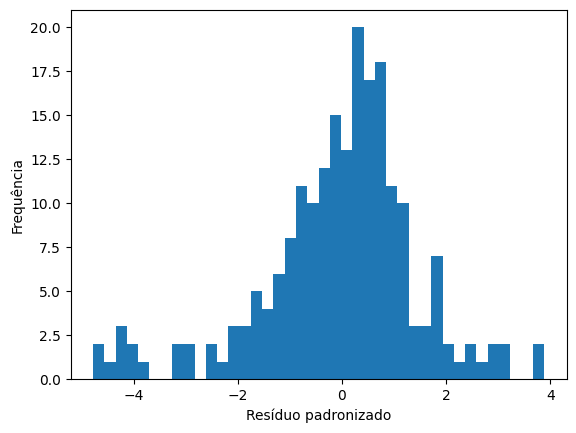

In [8]:
plt.hist(cv_results["z"], bins=40)
plt.xlabel("Resíduo padronizado")
plt.ylabel("Frequência")
plt.show()

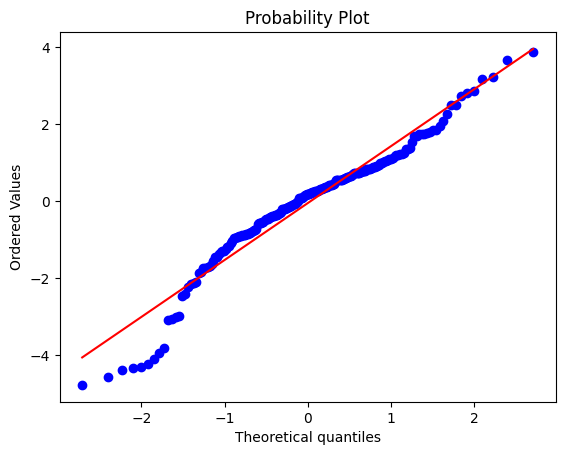

In [9]:
stats.probplot(
    cv_results["z"],
    dist="norm",
    plot=plt
)

plt.show()

In [10]:
lower = cv_results["mu"] - 1.96 * cv_results["sigma"]
upper = cv_results["mu"] + 1.96 * cv_results["sigma"]

coverage = (
    (cv_results["y_true"] >= lower) &
    (cv_results["y_true"] <= upper)
).mean()

print(coverage)

0.855072463768116


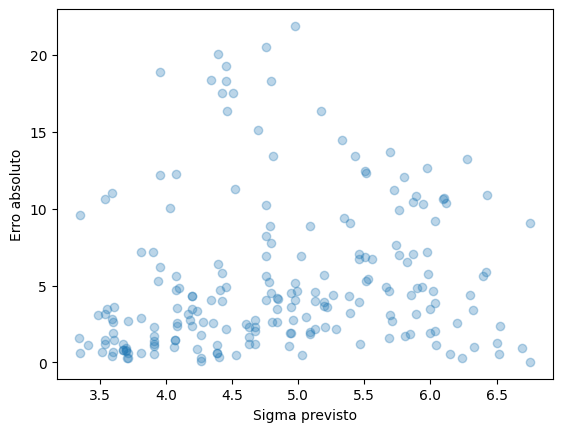

In [11]:
plt.scatter(
    cv_results["sigma"],
    cv_results["abs_error"],
    alpha=0.3
)

plt.xlabel("Sigma previsto")
plt.ylabel("Erro absoluto")
plt.show()

In [12]:
cv_results[["sigma", "abs_error"]].corr()

,sigma,abs_error
sigma,1.000000,0.156052
abs_error,0.156052,1.000000


In [13]:
spearmanr(
    cv_results["sigma"],
    cv_results["abs_error"]
)

SignificanceResult(statistic=np.float64(0.27315334423155985), pvalue=np.float64(6.828315368324366e-05))

In [14]:
rmse = np.sqrt(np.mean((cv_results["y_true"] - cv_results["mu"])**2))
sigma_mean = np.mean(cv_results["sigma"])

print(rmse, sigma_mean)

7.17308246622141 4.847552339459305


In [15]:
z = (cv_results["y_true"] - cv_results["mu"]) / cv_results["sigma"]

print(z.mean())
print(z.std())

-0.05891847914959103
1.504017020263821


In [16]:
cv_results["sigma"].describe()

,sigma
count,207.000000
mean,4.847552
std,0.883497
min,3.347757
25%,4.084777
50%,4.789184
75%,5.544493
max,6.754918


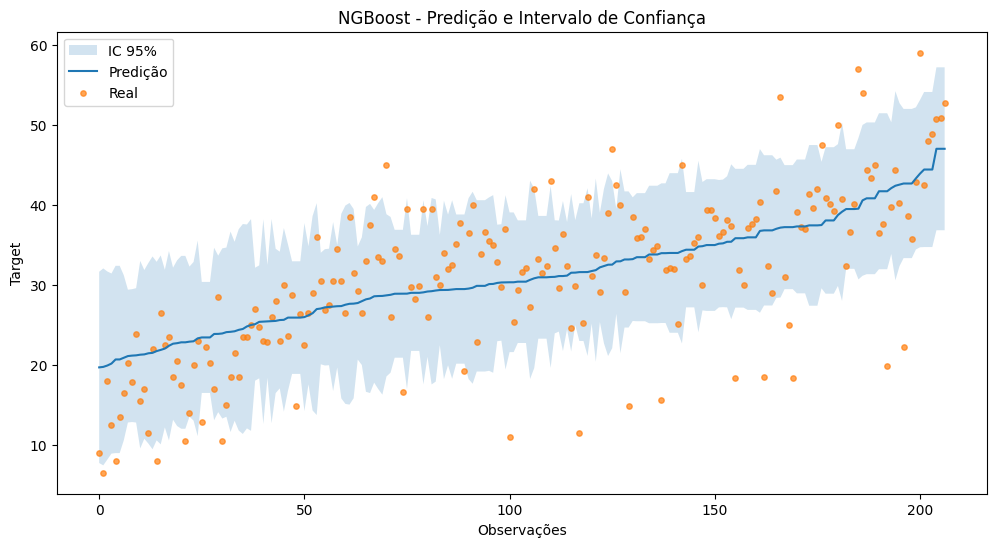

In [17]:
plot_df = cv_results.copy()

plot_df["lower"] = (
    plot_df["mu"] - 1.96 * plot_df["sigma"]
)

plot_df["upper"] = (
    plot_df["mu"] + 1.96 * plot_df["sigma"]
)

plot_df = plot_df.sort_values("mu")

x = np.arange(len(plot_df))

plt.figure(figsize=(12,6))

plt.fill_between(
    x,
    plot_df["lower"],
    plot_df["upper"],
    alpha=0.2,
    label="IC 95%"
)

plt.plot(
    x,
    plot_df["mu"],
    label="Predição"
)

plt.scatter(
    x,
    plot_df["y_true"],
    s=15,
    alpha=0.7,
    label="Real"
)

plt.legend()
plt.xlabel("Observações")
plt.ylabel("Target")
plt.title("NGBoost - Predição e Intervalo de Confiança")
plt.show()

## Gráfico menos poluido

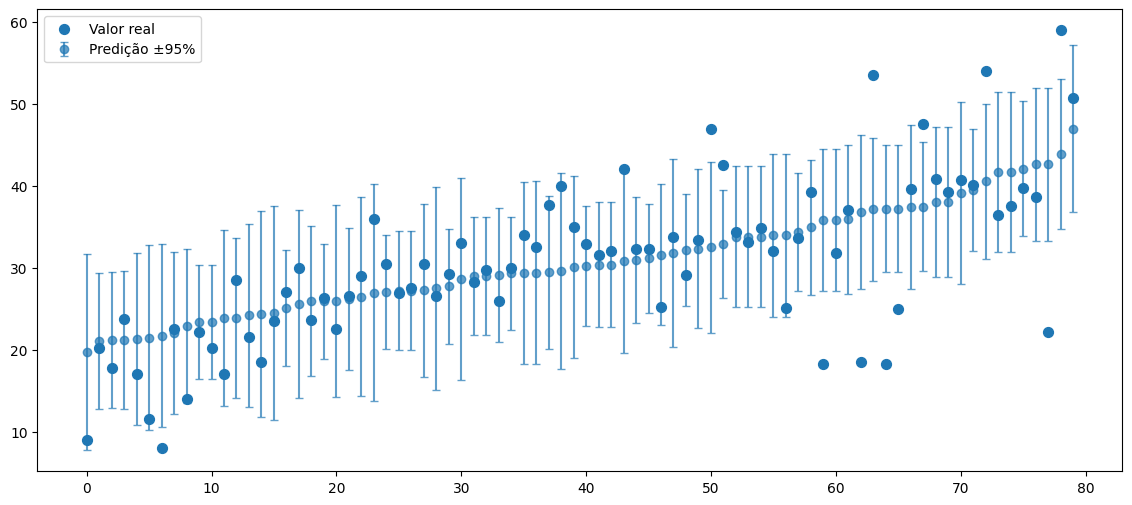

In [18]:
sample = cv_results.sample(
    80,
    random_state=42
).sort_values("mu")

x = np.arange(len(sample))

plt.figure(figsize=(14,6))

plt.errorbar(
    x,
    sample["mu"],
    yerr=1.96 * sample["sigma"],
    fmt="o",
    alpha=0.7,
    capsize=3,
    label="Predição ±95%"
)

plt.scatter(
    x,
    sample["y_true"],
    s=50,
    label="Valor real"
)
    
plt.legend()
plt.show()

## Observado vs Previsto

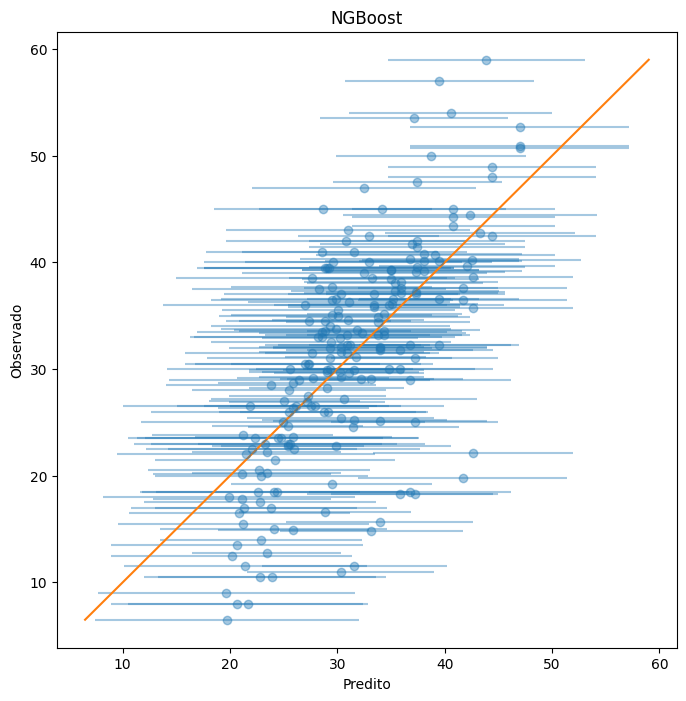

In [19]:
plt.figure(figsize=(8,8))

plt.errorbar(
    cv_results["mu"],
    cv_results["y_true"],
    xerr=1.96 * cv_results["sigma"],
    fmt="o",
    alpha=0.4
)

lims = [
    min(cv_results["y_true"].min(),
        cv_results["mu"].min()),
    max(cv_results["y_true"].max(),
        cv_results["mu"].max())
]

plt.plot(lims, lims)

plt.xlabel("Predito")
plt.ylabel("Observado")
plt.title("NGBoost")
plt.show()

## Observações fora de faixa

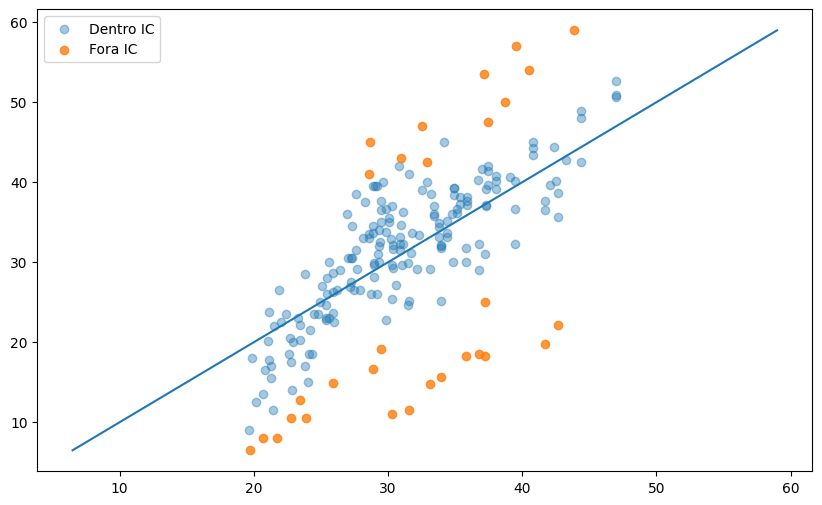

In [20]:
cv_results["lower"] = (
    cv_results["mu"] -
    1.96 * cv_results["sigma"]
)

cv_results["upper"] = (
    cv_results["mu"] +
    1.96 * cv_results["sigma"]
)

cv_results["inside"] = (
    (cv_results["y_true"] >= cv_results["lower"])
    &
    (cv_results["y_true"] <= cv_results["upper"])
)

plt.figure(figsize=(10,6))

plt.scatter(
    cv_results.loc[cv_results.inside, "mu"],
    cv_results.loc[cv_results.inside, "y_true"],
    alpha=0.4,
    label="Dentro IC"
)

plt.scatter(
    cv_results.loc[~cv_results.inside, "mu"],
    cv_results.loc[~cv_results.inside, "y_true"],
    alpha=0.8,
    label="Fora IC"
)

lims = [
    min(cv_results["mu"].min(),
        cv_results["y_true"].min()),
    max(cv_results["mu"].max(),
        cv_results["y_true"].max())
]

plt.plot(lims, lims)

plt.legend()
plt.show()

In [21]:
print("R²:", r2_score(cv_results["y_true"], cv_results["mu"]) * 100)
print("RMSE:", root_mean_squared_error(cv_results["y_true"], cv_results["mu"]))
print("MAE:", mean_absolute_error(cv_results["y_true"], cv_results["mu"]))
print("MAPE:", mean_absolute_percentage_error(cv_results["y_true"], cv_results["mu"]))

R²: 50.5303565632895
RMSE: 7.17308246622141
MAE: 5.29298293788714
MAPE: 0.2352466649783025
